#Common Words

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from collections import Counter

from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud

In [ ]:
speech_df = pd.read_csv('lemma.csv')
data = pd.read_csv('data_dtm_lemma.csv')
data = data.transpose()
data.head()

,0,1,2,3,4,5,6,7,8,9,...,312,313,314,315,316,317,318,319,320,321
Unnamed: 0,0,1,2,3,4,5,6,7,8,9,...,312,313,314,315,316,317,318,319,320,321
aa,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aahhhh,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aaron,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
aback,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = data.iloc[1: , :]
data.head()

,0,1,2,3,4,5,6,7,8,9,...,312,313,314,315,316,317,318,319,320,321
aa,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aahhhh,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aaron,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
aback,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
abalthus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Find the top 30 words said in each speech
top_dict = {}
for c in data.columns:
    top = data[c].sort_values(ascending=False).head(30)
    top_dict[c]= list(zip(top.index, top.values))

# top_dict

In [ ]:
# Find the most common top words among all speeches

# Let's first pull out the top 30 words for each speech
words = []
for speech in data.columns:
    top = [word for (word, count) in top_dict[speech]]
    for t in top:
        words.append(t)

boring_words = ['say','like','just','dont','don','im',
                'ive','youll','youve','things','thing','youre','right','really','lot',
                'make','know','people','way',
                'come','thats','graduate','college']

In [ ]:
most_common = pd.DataFrame(Counter([word for word in words if word not in boring_words]).most_common()[:20],
                          columns=['word','freq'])
most_common

,word,freq
0,time,205
1,life,201
2,think,186
3,world,162
4,years,159
5,want,157
6,work,151
7,live,140
8,tell,126
9,today,107


<ipython-input-20-0c69b30ee492>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='word',y='freq',data=most_common, palette='Spectral')


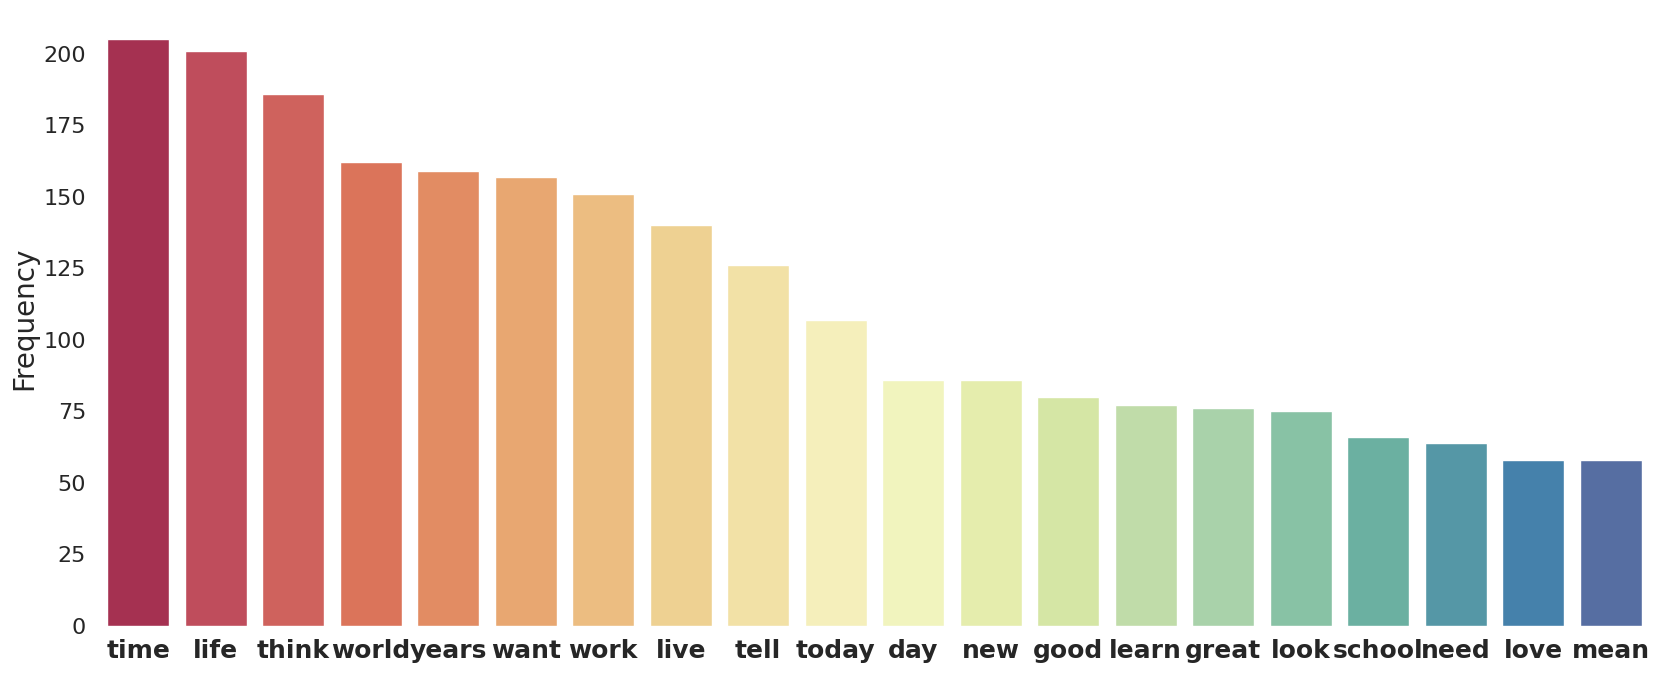

In [ ]:
fig, ax = plt.subplots(figsize=[20,8])
sns.barplot(x='word',y='freq',data=most_common, palette='Spectral')

# ax.set_title('Most commonly used words among all addresses',fontsize=20)
ax.set_ylabel('Frequency',fontsize=20)
ax.set_xlabel('',fontsize=30)
plt.box(on=None)
plt.xticks(fontsize=18,fontweight='bold')
plt.yticks(fontsize=16);
fig.savefig('most_common_words.pdf', bbox_inches='tight', transparent=True)

In [ ]:
common_words = [word for word, count in Counter(words).most_common() if count > 70]
common_words

['make',
 'know',
 'say',
 'time',
 'people',
 'life',
 'think',
 'like',
 'world',
 'years',
 'want',
 'come',
 'work',
 'dont',
 'live',
 'tell',
 'today',
 'im',
 'way',
 'youre',
 'day',
 'new',
 'things',
 'right',
 'graduate',
 'good',
 'learn',
 'great',
 'look']

#School Statistics

In [ ]:
speech_speaker_school = pd.read_csv('final.csv')
speech_speaker_school.head()

,speaker,profession,category,year,school,transcript,length,latitude,longitude
0,OPRAH WINFREY,host and television producer,Entertainment,1918,USC,thank you wallis annenberg and a special thank...,15301,34.022415,-118.285530
1,OPRAH WINFREY,host and television producer,Entertainment,2007,HOWARD UNIVERSITY,president swygert trustees distinguished guest...,14168,38.922684,-77.019438
2,FRANKLIN D ROOSEVELT,Politician,Politics,1932,OGLETHORPE UNIVERSITY,for me as for you this is a day of honorable a...,16017,33.912594,-84.325560
3,WILLIAM ALLEN,"Author, Political Scientist",Publish,1936,WHITE NORTHWESTERN UNIVERSITY,about all that a commencement orator can do fo...,14953,42.055984,-87.675171
4,CARRIE CHAPMAN,Women's suffrage leader,Politics,1936,CATT SWEET BRIAR COLLEGE,i bring a message to sweet briar college and e...,22942,37.557809,-79.082886


In [ ]:
speech_speaker_school['latitude'] = speech_speaker_school['latitude'].astype('float')
speech_speaker_school['longitude'] = speech_speaker_school['longitude'].astype('float')

In [ ]:
# West coast: longitude < -109
# Central: -109 < longitude < -88
# East: longitude > -88

In [ ]:
speech_speaker_school['region'] = speech_speaker_school['longitude'].apply(lambda x: 'West' if x < -109 else(\
                                                                            'Central' if -109 < x < -88\
                                                                            else 'East'))
speech_speaker_school.head()

,speaker,profession,category,year,school,transcript,length,latitude,longitude,region
0,OPRAH WINFREY,host and television producer,Entertainment,1918,USC,thank you wallis annenberg and a special thank...,15301,34.022415,-118.285530,West
1,OPRAH WINFREY,host and television producer,Entertainment,2007,HOWARD UNIVERSITY,president swygert trustees distinguished guest...,14168,38.922684,-77.019438,East
2,FRANKLIN D ROOSEVELT,Politician,Politics,1932,OGLETHORPE UNIVERSITY,for me as for you this is a day of honorable a...,16017,33.912594,-84.325560,East
3,WILLIAM ALLEN,"Author, Political Scientist",Publish,1936,WHITE NORTHWESTERN UNIVERSITY,about all that a commencement orator can do fo...,14953,42.055984,-87.675171,East
4,CARRIE CHAPMAN,Women's suffrage leader,Politics,1936,CATT SWEET BRIAR COLLEGE,i bring a message to sweet briar college and e...,22942,37.557809,-79.082886,East


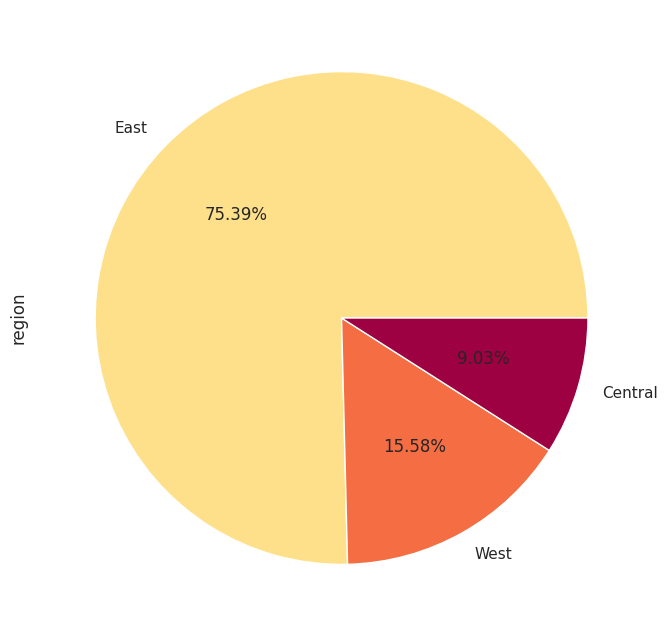

In [ ]:
plt.rcParams['figure.figsize'] = [20, 8]
colours = ['#fee08b','#f46d43','#9e0142']
speech_speaker_school.region.value_counts().plot(kind='pie', colors=colours, autopct = "%.2f%%");

#Speaker Profession

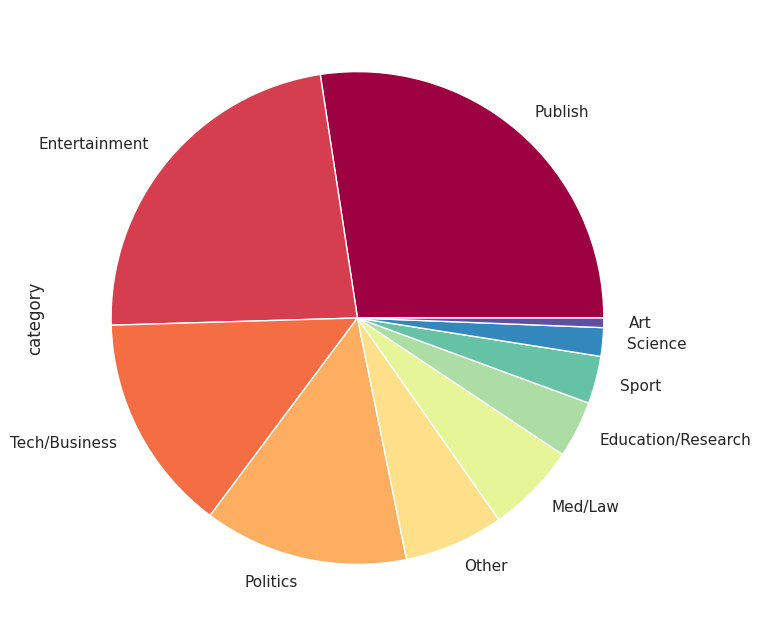

In [ ]:
plt.rcParams['figure.figsize'] = [20, 8]
colours = ['#9e0142','#d53e4f','#f46d43','#fdae61','#fee08b','#e6f598','#abdda4','#66c2a5','#3288bd','#5e4fa2']
speech_speaker_school.category.value_counts().plot(kind='pie',colors=colours);